# Monotone-Y signed gap: code-capacity experiments

This notebook uses the sampling and analysis workflow of `path_gap_getting_started.ipynb` for the final-correction **monotone-Y signed gap**. It runs in the ordinary **color_code_so** kernel. The feature metric loads automatically from its separate worktree.

The score is $S_Y(E)=\min_{L\in\mathcal Y}[W(E\oplus L)-W(E)]$, the exact minimum within the certified monotone-Y family. It bounds the correction-relative unrestricted logical minimum from above; equality with a full logical-class gap and posterior calibration are not established. Negative scores remain signed.

The configuration below mirrors the reference notebook: d=9,13,15, p=.04/.05, one million shots per point (six million total). Sampling starts only when `RUN_NEW_EXPERIMENT=True`. Initially this notebook analyzes a bounded 128-shot-per-point validation run; that sample cannot establish performance superiority. See [usage and validation](../notes/support/MONOTONE_Y_EXPERIMENT.md).


In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from IPython.display import display
from color_code_softoutput.experiments.monotone_y_test import MonotoneYTestConfig, run_experiment, require_monotone_y
from color_code_softoutput.simulation.config import PROJECT_ROOT
from color_code_softoutput.analysis.monotone_y import MonotoneYDataset, audit_run, matched_retention
from color_code_softoutput.analysis.swim_distribution import SwimDistanceDistributionPlotter
from color_code_softoutput.analysis.conditional_ler import ConditionalLERAnalyzer
from color_code_softoutput.analysis.postselection import PostSelectionAnalyzer
from color_code_softoutput.analysis.prior_work import LeeFig3ReproductionAnalyzer
from color_code_softoutput.analysis.figure_style import RevtexFigureStyle

style = RevtexFigureStyle()  # same publication style / 99% Wilson bands
require_monotone_y()


_color_code_softoutput_monotone_y.metrics._physical_correction_adapter.MonotoneYGapAdapter

In [6]:
shots_per_point = 1_000_000
num_workers = 8
batch_size = 4_000
master_seed = 0
config = MonotoneYTestConfig(
    distances=(11, 13, 15), near_threshold_ps=(), subthreshold_ps=(.04, .05),
    shots_per_point=shots_per_point, num_workers=num_workers,
    batch_size=batch_size, master_seed=master_seed)
print('Full experiment shots:', len(config.distances)*len(config.probabilities)*config.shots_per_point)
config.resolved()


Full experiment shots: 6000000


{'distances': (11, 13, 15),
 'near_threshold_ps': (),
 'subthreshold_ps': (0.04, 0.05),
 'shots_per_point': 1000000,
 'batch_size': 4000,
 'num_workers': 8,
 'master_seed': 0,
 'output_root': '/home/quantum_teresheys/workspace/color_code_softoutput/results',
 'verbose': True}

## Sample or load a run

Each physical shot is decoded by both ordinary and comparative decoders. The metric reads each decoder's final correction; the hard decisions stay unchanged. The comparative input contains a zero bookkeeping detector, never the true observable.

New runs save `ordinary_monotone_y_gap`, `comparative_monotone_y_gap`, `forced_gap`, each decoder's failure label, correction weight, minimizing physical root/template IDs, and the fixed version `monotone_y_signed_v1`. The selected hard-decoder color is recorded separately; it is not used to construct or select the monotone-Y score.

Existing path-gap/SWIM datasets do not contain this metric. Use a completed monotone-Y run below, or enable new sampling. Run metadata always identifies the actual saved configuration.


In [7]:
RUN_NEW_EXPERIMENT = True
SMOKE = False  # True: use 128 shots/point on the configured grid
existing_run = None  # None loads the latest completed *_monotone_y_test run
if RUN_NEW_EXPERIMENT:
    from dataclasses import replace
    run_directory = run_experiment(replace(config, shots_per_point=128) if SMOKE else config)
elif existing_run is not None:
    run_directory = Path(existing_run)
else:
    import json
    candidates = [p.parent for p in config.output_root.glob('*_monotone_y_test/metadata.json')
                  if json.loads(p.read_text()).get('status') == 'sampling_complete']
    if not candidates:
        raise FileNotFoundError('Run the documented --smoke command or enable RUN_NEW_EXPERIMENT with SMOKE=True.')
    run_directory = sorted(candidates)[-1]
dataset = MonotoneYDataset(run_directory)
print(run_directory)
print('Saved metric version:', dataset.metric_version)
print('Actual saved shots/point:', dataset.metadata['resolved_config']['shots_per_point'])
dataset.available_values()


monotone-Y: 4000/6000000 shots; 19.9s
monotone-Y: 8000/6000000 shots; 20.0s
monotone-Y: 12000/6000000 shots; 20.2s
monotone-Y: 16000/6000000 shots; 20.3s
monotone-Y: 20000/6000000 shots; 20.4s
monotone-Y: 24000/6000000 shots; 20.5s
monotone-Y: 28000/6000000 shots; 20.6s
monotone-Y: 32000/6000000 shots; 20.7s
monotone-Y: 36000/6000000 shots; 21.8s
monotone-Y: 40000/6000000 shots; 21.9s
monotone-Y: 44000/6000000 shots; 22.0s
monotone-Y: 48000/6000000 shots; 22.1s
monotone-Y: 52000/6000000 shots; 22.2s
monotone-Y: 56000/6000000 shots; 22.3s
monotone-Y: 60000/6000000 shots; 22.4s
monotone-Y: 64000/6000000 shots; 22.6s
monotone-Y: 68000/6000000 shots; 23.8s
monotone-Y: 72000/6000000 shots; 24.0s
monotone-Y: 76000/6000000 shots; 24.1s
monotone-Y: 80000/6000000 shots; 24.2s
monotone-Y: 84000/6000000 shots; 24.3s
monotone-Y: 88000/6000000 shots; 24.4s
monotone-Y: 92000/6000000 shots; 24.5s
monotone-Y: 96000/6000000 shots; 24.6s
monotone-Y: 100000/6000000 shots; 25.7s
monotone-Y: 104000/6000000

{'distance': [11, 13, 15], 'physical_error_rate': [0.04, 0.05]}

In [4]:
REPLAY = False  # True replays the first saved batch of EVERY (d,p); no new independent sample
report = audit_run(dataset, replay=REPLAY)
display(report)
if report['source_drift']:
    print('Source files have changed; see source_snapshot.zip for the exact run sources.')
prior = LeeFig3ReproductionAnalyzer(style).analyze(dataset)
display(prior['crossing'], prior['fits'], prior['trends'])


{'passed': True,
 'shots': 768,
 'batches': 12,
 'replayed_batches': 0,
 'source_drift': ['src/color_code_softoutput/analysis/postselection.py'],
 'exact_source_match': False}

Source files have changed; see source_snapshot.zip for the exact run sources.


{'threshold': None, 'status': 'insufficient_curves', 'variance': None}

,distance,points_used,points_excluded,excluded_probabilities,fit_status,total_failures,G,C,G_se,C_se,G_low,G_high,C_low,C_high
0,9,2,0,[],insufficient_nonzero_points,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13,0,2,"[0.04, 0.05]",insufficient_nonzero_points,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,15,0,2,"[0.04, 0.05]",insufficient_nonzero_points,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,parameter,distances_used,fit_status,slope,intercept,slope_se,slope_low,slope_high
0,G,0,insufficient_distances,NaN,NaN,NaN,NaN,NaN
1,C,0,insufficient_distances,NaN,NaN,NaN,NaN,NaN


## Distributions and conditional logical error rate

The ordinary score uses ordinary decoder failures; the comparative score and forced gap use comparative failures. Markers are `o` for success and `x` for failure. Failure labels never change the sign of a score. The logistic fit is an empirical model, with explicit statuses when the data do not identify a fit.

The fixed-p distribution overlays ordinary monotone-Y (green) and forced gap (blue). Each metric is normalized using its own success/failure counts. Figures and tables use distinct metric filenames.


In [4]:
values = dataset.available_values()
distances = [d for d in (5, 7, 9, 11) if d in values['distance']] or values['distance']
p = .04 if .04 in values['physical_error_rate'] else values['physical_error_rate'][0]
selection = dict(distance=distances, physical_error_rate=p)
include_forced_gap = True  # False: show only ordinary monotone-Y gap
# figure, distribution = SwimDistanceDistributionPlotter(style).plot(
#     dataset, **selection, metric='ordinary_monotone_y_gap', normalize_frequency=True,
#     include_forced_gap=include_forced_gap)
# distribution_filename = ('monotone_y_gap_with_forced_gap_distribution_counts.parquet'
#                          if include_forced_gap else 'monotone_y_gap_distribution_counts.parquet')
# distribution.to_parquet(run_directory / distribution_filename, index=False)
# display(figure)


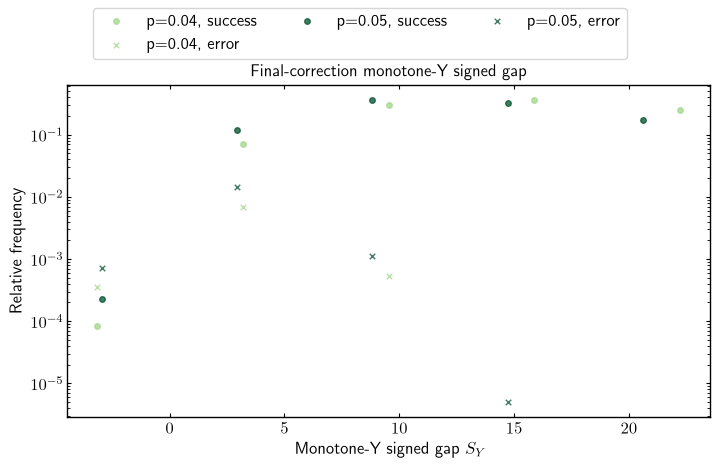

In [7]:
fixed_d = 7 if 7 in values['distance'] else values['distance'][0]
probabilities = [p for p in (.02, .03, .04, .05) if p in values['physical_error_rate']]
figure, distribution_p = SwimDistanceDistributionPlotter(style).plot(
    dataset, distance=fixed_d, physical_error_rate=probabilities or values['physical_error_rate'],
    metric='ordinary_monotone_y_gap', normalize_frequency=True)
distribution_p.to_parquet(run_directory / 'monotone_y_gap_distribution_p_counts.parquet', index=False)
display(figure)


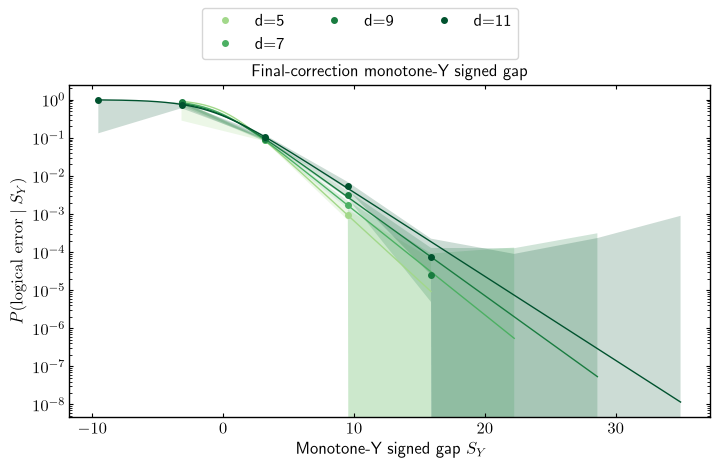

,shots,failures,fit_status,k,l,k_se,l_se,k_low,k_high,l_low,l_high,distance,physical_error_rate,varying_parameter,varying_value
0,200000,2782,ok,0.725347,0.068451,0.018961,0.066499,0.676506,0.774188,-0.102839,0.239741,5,0.04,distance,5
1,200000,1530,ok,0.632263,0.356894,0.014525,0.059307,0.594850,0.669677,0.204131,0.509658,7,0.04,distance,7
2,200000,877,ok,0.569140,0.459364,0.013154,0.064753,0.535259,0.603021,0.292572,0.626155,9,0.04,distance,9
3,200000,482,ok,0.508085,0.512473,0.013355,0.082159,0.473686,0.542484,0.300846,0.724100,11,0.04,distance,11


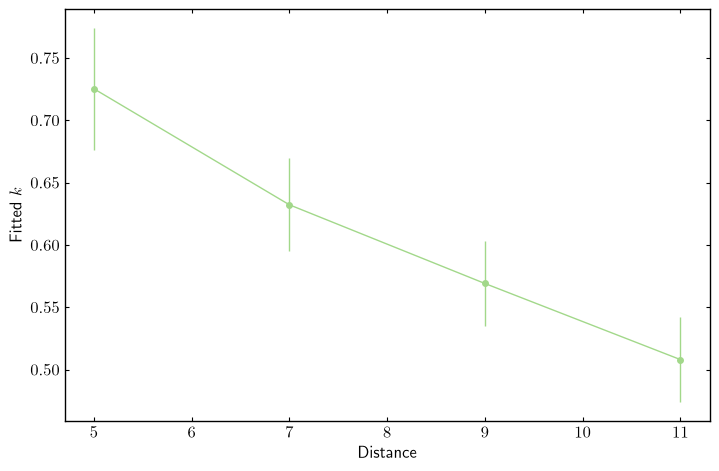

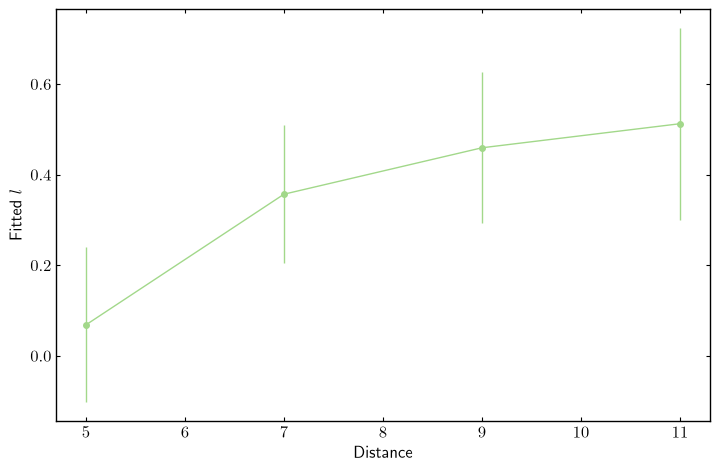

In [8]:
conditional = ConditionalLERAnalyzer(style)
figure, rates, fits = conditional.plot(dataset, **selection, metric='ordinary_monotone_y_gap')
rates.to_parquet(run_directory / 'monotone_y_gap_conditional_rates.parquet', index=False)
display(figure, fits)
for figure in conditional.plot_parameters(fits, output_directory=run_directory / 'figures', suffix='monotone_y_gap_distance'):
    display(figure)


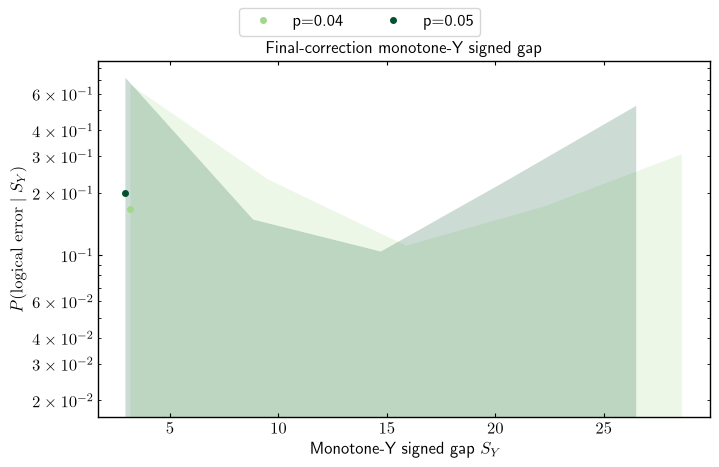

,shots,failures,fit_status,k,l,k_se,l_se,k_low,k_high,l_low,l_high,distance,physical_error_rate,varying_parameter,varying_value
0,128,1,perfect_or_quasi_separation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,0.04,physical_error_rate,0.04
1,128,1,perfect_or_quasi_separation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,0.05,physical_error_rate,0.05


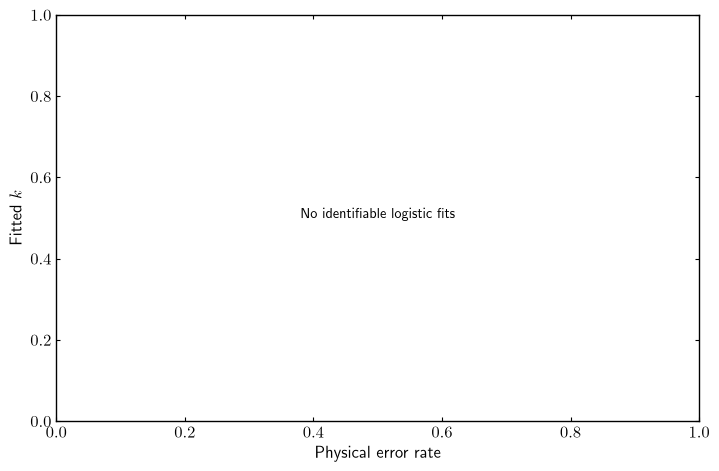

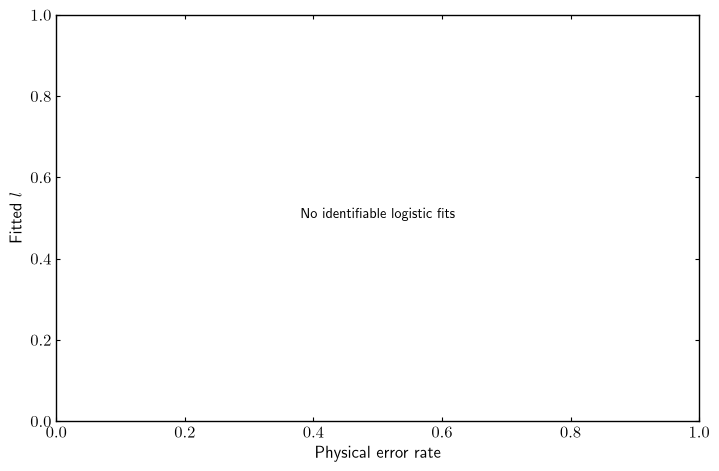

In [8]:
figure, rates_p, fits_p = conditional.plot(
    dataset, distance=fixed_d, physical_error_rate=probabilities or values['physical_error_rate'],
    metric='ordinary_monotone_y_gap')
rates_p.to_parquet(run_directory / 'monotone_y_gap_conditional_p_rates.parquet', index=False)
display(figure, fits_p)
for figure in conditional.plot_parameters(fits_p, output_directory=run_directory / 'figures', suffix='monotone_y_gap_probability'):
    display(figure)


## Threshold post-selection and matched retention

Threshold curves retain `score >= threshold`, keeping whole ties. Wilson bands are 99% pointwise intervals. Zero-failure rows remain in saved tables even though zero cannot be displayed on a logarithmic axis.

1. Ordinary monotone-Y selection uses the ordinary decoder's failures.
2. Ordinary monotone-Y versus forced gap compares pipelines with different hard decisions on the same physical shots.
3. Comparative monotone-Y versus forced gap compares scores using the same hard decisions and failure labels.

Marker shapes identify the soft output: ordinary monotone-Y uses circles (`o`), comparative monotone-Y triangles (`^`), and forced gap squares (`s`). The same shapes apply in the expanded view.


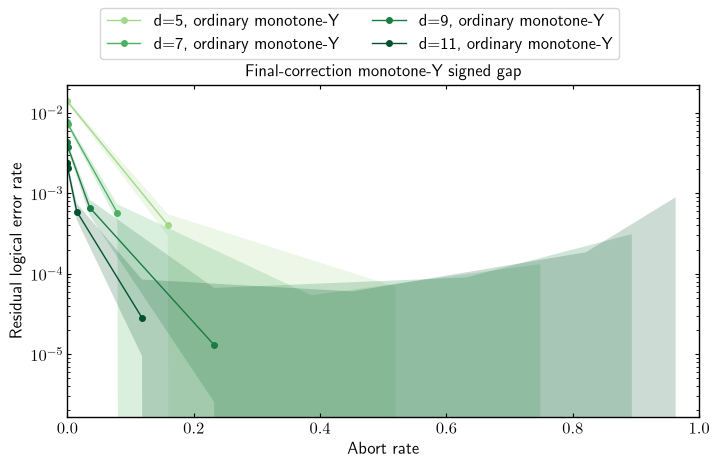

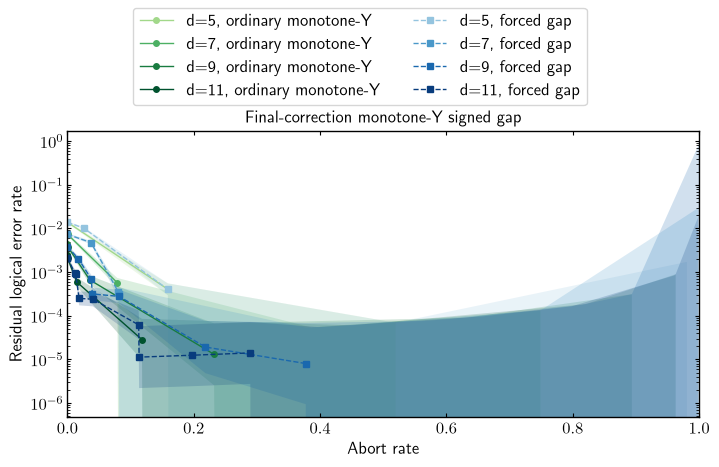

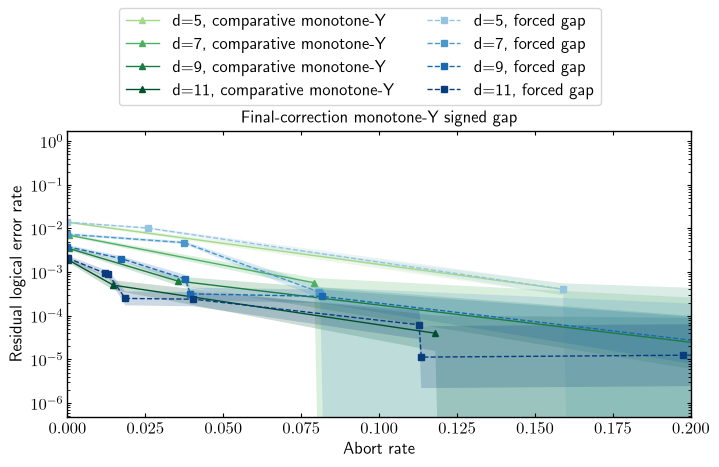

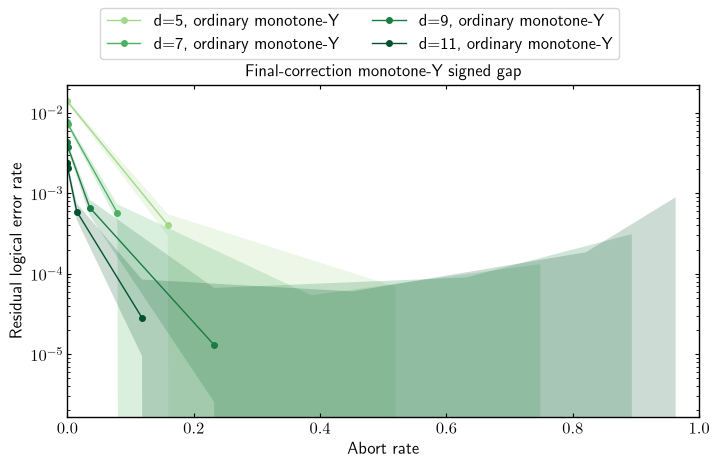

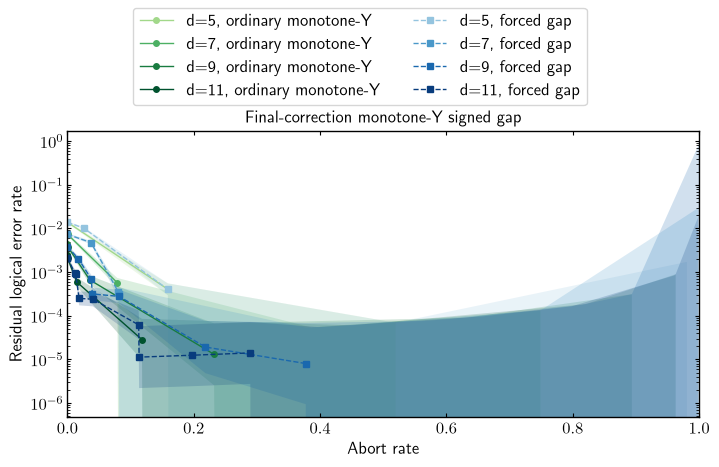

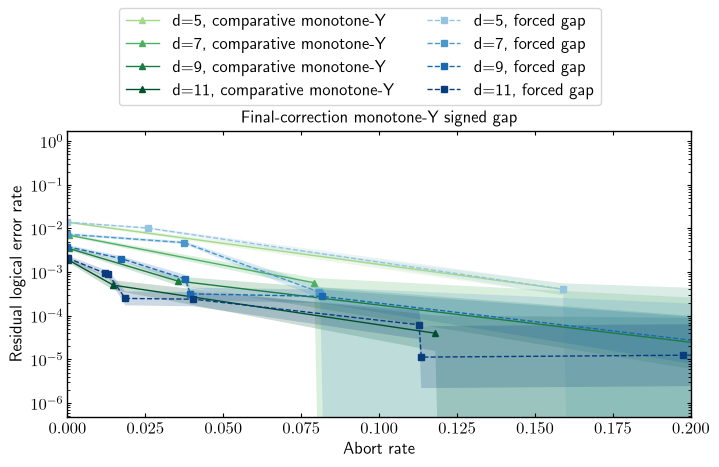

In [5]:
postselection = PostSelectionAnalyzer(style)
figure, ordinary_curve = postselection.plot(dataset, **selection, metrics=('ordinary_monotone_y_gap',))
display(figure)
figure, paired_curve = postselection.plot(dataset, **selection, metrics=('ordinary_monotone_y_gap', 'forced_gap'))
display(figure)
figure, same_decoder_curve = postselection.plot(dataset, **selection, metrics=('comparative_monotone_y_gap', 'forced_gap'), xlim = (0.0, 0.2))
display(figure)


In [ ]:
matched = matched_retention(dataset, **selection, fractions=(1., .9, .75, .5))
matched.to_parquet(run_directory / 'monotone_y_gap_matched_retention.parquet', index=False)
display(matched[['distance', 'physical_error_rate', 'metric', 'target_retained',
                 'retained_shots', 'retained_failures', 'residual_logical_error_rate', 'low', 'high']])


Matched-retention tables split only the boundary tie by stable shot identity, independently of failure labels. This differs from threshold plots, which keep whole ties. Scores are not rounded by default; use the same explicit `round_digits` for all methods when studying rounding sensitivity.

Each run contains shot Parquet files, count summaries, batch timings, configuration and dependency provenance, source snapshots, PDF/PNG figures and analysis tables. Replaying requires the saved seeds and batch size; a seed alone does not guarantee identical shots across Stim versions. The prior-work analysis above reports insufficient coverage when this subthreshold-only grid cannot support a crossing or scaling fit.


## Quantitative post-selection comparison

This cell analyzes saved shots only. Reduction rate is `1 - retained LER / each decoder's baseline LER`; the residual-LER ratio divides by forced-gap LER. Matched-abort tables split boundary ties by shot ID. Separate whole-tie tables use actual attainable thresholds and report the actual abort fraction.

The configurable 1.25 margin is a descriptive point-estimate criterion. It does not establish statistical equivalence. Ratios with zero reference failures remain undefined, and low counts are flagged in the report.


In [11]:
from IPython.display import Markdown, display
from color_code_softoutput.analysis.monotone_y import compare_postselection

# 既存の dataset と selection（図と同じ距離・p）を使用。新規サンプリングなし。
abort_rates = (0., .01, .025, .05, .1, .15, .2, .25, .3, .5)
competitive_margin = 1.25  # 残存LERがforced gapの1.25倍以内という参考基準
quantitative = compare_postselection(
    dataset, **selection, abort_rates=abort_rates,
    competitive_margin=competitive_margin, round_digits=None,
    output_directory=dataset.run_directory / 'monotone_y_comparison')
comparison = quantitative['comparison']
columns = ['distance', 'physical_error_rate', 'target_abort_rate']
for name in ('ordinary_monotone_y_gap', 'comparative_monotone_y_gap', 'forced_gap'):
    columns += [f'{name}_actual_abort_rate', f'{name}_residual_ler',
                f'{name}_reduction_rate', f'{name}_retained_failures']
columns += ['ordinary_monotone_y_gap_ler_ratio_to_forced', 'comparative_monotone_y_gap_ler_ratio_to_forced',
            'ordinary_monotone_y_gap_low_count_warning', 'comparative_monotone_y_gap_low_count_warning']
print('同じabort rate（境界同点分割）：')
display(comparison.loc[comparison.policy == 'matched_abort', columns])
print('図と同じwhole-tie threshold（actual_abort_rateは手法間で異なる場合があります）：')
display(comparison.loc[comparison.policy == 'whole_ties', columns])
display(Markdown(quantitative['report']))
print('Saved report:', quantitative['report_path'])


同じabort rate（境界同点分割）：


,distance,physical_error_rate,target_abort_rate,ordinary_monotone_y_gap_actual_abort_rate,ordinary_monotone_y_gap_residual_ler,ordinary_monotone_y_gap_reduction_rate,ordinary_monotone_y_gap_retained_failures,comparative_monotone_y_gap_actual_abort_rate,comparative_monotone_y_gap_residual_ler,comparative_monotone_y_gap_reduction_rate,comparative_monotone_y_gap_retained_failures,forced_gap_actual_abort_rate,forced_gap_residual_ler,forced_gap_reduction_rate,forced_gap_retained_failures,ordinary_monotone_y_gap_ler_ratio_to_forced,comparative_monotone_y_gap_ler_ratio_to_forced,ordinary_monotone_y_gap_low_count_warning,comparative_monotone_y_gap_low_count_warning
0,9,0.04,0.000,0.000000,0.007812,0.000000,1.0,0.000000,0.007812,0.000000,1.0,0.000000,0.007812,0.000000,1.0,1.0,1.0,True,True
1,9,0.04,0.010,0.007812,0.007874,-0.007874,1.0,0.007812,0.007874,-0.007874,1.0,0.007812,0.007874,-0.007874,1.0,1.0,1.0,True,True
2,9,0.04,0.025,0.023438,0.008000,-0.024000,1.0,0.023438,0.008000,-0.024000,1.0,0.023438,0.008000,-0.024000,1.0,1.0,1.0,True,True
3,9,0.04,0.050,0.046875,0.000000,1.000000,0.0,0.046875,0.000000,1.000000,0.0,0.046875,0.000000,1.000000,0.0,NaN,NaN,True,True
4,9,0.04,0.100,0.093750,0.000000,1.000000,0.0,0.093750,0.000000,1.000000,0.0,0.093750,0.000000,1.000000,0.0,NaN,NaN,True,True
5,9,0.04,0.150,0.148438,0.000000,1.000000,0.0,0.148438,0.000000,1.000000,0.0,0.148438,0.000000,1.000000,0.0,NaN,NaN,True,True
6,9,0.04,0.200,0.195312,0.000000,1.000000,0.0,0.195312,0.000000,1.000000,0.0,0.195312,0.000000,1.000000,0.0,NaN,NaN,True,True
7,9,0.04,0.250,0.250000,0.000000,1.000000,0.0,0.250000,0.000000,1.000000,0.0,0.250000,0.000000,1.000000,0.0,NaN,NaN,True,True
8,9,0.04,0.300,0.296875,0.000000,1.000000,0.0,0.296875,0.000000,1.000000,0.0,0.296875,0.000000,1.000000,0.0,NaN,NaN,True,True
9,9,0.04,0.500,0.500000,0.000000,1.000000,0.0,0.500000,0.000000,1.000000,0.0,0.500000,0.000000,1.000000,0.0,NaN,NaN,True,True


図と同じwhole-tie threshold（actual_abort_rateは手法間で異なる場合があります）：


,distance,physical_error_rate,target_abort_rate,ordinary_monotone_y_gap_actual_abort_rate,ordinary_monotone_y_gap_residual_ler,ordinary_monotone_y_gap_reduction_rate,ordinary_monotone_y_gap_retained_failures,comparative_monotone_y_gap_actual_abort_rate,comparative_monotone_y_gap_residual_ler,comparative_monotone_y_gap_reduction_rate,comparative_monotone_y_gap_retained_failures,forced_gap_actual_abort_rate,forced_gap_residual_ler,forced_gap_reduction_rate,forced_gap_retained_failures,ordinary_monotone_y_gap_ler_ratio_to_forced,comparative_monotone_y_gap_ler_ratio_to_forced,ordinary_monotone_y_gap_low_count_warning,comparative_monotone_y_gap_low_count_warning
10,9,0.04,0.000,0.000000,0.007812,0.0,1.0,0.000000,0.007812,0.0,1.0,0.000000,0.007812,0.000000,1.0,1.000000,1.000000,True,True
11,9,0.04,0.010,0.000000,0.007812,0.0,1.0,0.000000,0.007812,0.0,1.0,0.007812,0.007874,-0.007874,1.0,0.992188,0.992188,True,True
12,9,0.04,0.025,0.000000,0.007812,0.0,1.0,0.000000,0.007812,0.0,1.0,0.007812,0.007874,-0.007874,1.0,0.992188,0.992188,True,True
13,9,0.04,0.050,0.046875,0.000000,1.0,0.0,0.046875,0.000000,1.0,0.0,0.046875,0.000000,1.000000,0.0,NaN,NaN,True,True
14,9,0.04,0.100,0.046875,0.000000,1.0,0.0,0.046875,0.000000,1.0,0.0,0.070312,0.000000,1.000000,0.0,NaN,NaN,True,True
15,9,0.04,0.150,0.046875,0.000000,1.0,0.0,0.046875,0.000000,1.0,0.0,0.070312,0.000000,1.000000,0.0,NaN,NaN,True,True
16,9,0.04,0.200,0.046875,0.000000,1.0,0.0,0.046875,0.000000,1.0,0.0,0.070312,0.000000,1.000000,0.0,NaN,NaN,True,True
17,9,0.04,0.250,0.218750,0.000000,1.0,0.0,0.218750,0.000000,1.0,0.0,0.210938,0.000000,1.000000,0.0,NaN,NaN,True,True
18,9,0.04,0.300,0.218750,0.000000,1.0,0.0,0.218750,0.000000,1.0,0.0,0.210938,0.000000,1.000000,0.0,NaN,NaN,True,True
19,9,0.04,0.500,0.218750,0.000000,1.0,0.0,0.218750,0.000000,1.0,0.0,0.382812,0.000000,1.000000,0.0,NaN,NaN,True,True


# Monotone-Y post-selection 定量比較

Run: `/home/quantum_teresheys/workspace/color_code_softoutput/results/20260919_120559_210504_monotone_y_test`

削減率 = 1 − 選別後LER / 各デコーダの選別前LER。削減倍率 = 選別前LER / 選別後LER。
残存LER比 = Monotone-Y LER / forced-gap LER（小さいほど良い、1で同じ）。
参考判定の許容倍率は 1.25。これはユーザー指定可能な記述的基準で、統計的な同等性の証明ではありません。

ordinary Monotone-Y 対 forced gap は異なる hard decoder のパイプライン比較。comparative Monotone-Y 対 forced gap は同じ hard decoder のスコア比較。
各手法の残存失敗数・99% Wilson区間は counts.csv に保存。20未満の残存失敗数には低カウント警告を付ける（20は検定基準ではない）。
両方ゼロ失敗でも同等とは判定しない。forced gapがゼロ失敗なら比は未定義。ゼロ失敗時の削減率100%も観測値のみで、真のLERがゼロという意味ではない。

## 同一 abort rate（境界同点のみ shot ID で分割）

| d | p | abort | ordinary 残存失敗 | forced 残存失敗 | ordinary 削減率 | forced 削減率 | ordinary/forced LER | comparative/forced LER | 低カウント |
|---|---|---|---|---|---|---|---|---|---|
| 9 | 0.04 | 0.00% | 1 | 1 | 0.00% | 0.00% | 1 | 1 | あり |
| 9 | 0.04 | 0.78% | 1 | 1 | -0.79% | -0.79% | 1 | 1 | あり |
| 9 | 0.04 | 2.34% | 1 | 1 | -2.40% | -2.40% | 1 | 1 | あり |
| 9 | 0.04 | 4.69% | 0 | 0 | 100.00% | 100.00% | 未定義 | 未定義 | あり |
| 9 | 0.04 | 9.38% | 0 | 0 | 100.00% | 100.00% | 未定義 | 未定義 | あり |
| 9 | 0.04 | 14.84% | 0 | 0 | 100.00% | 100.00% | 未定義 | 未定義 | あり |
| 9 | 0.04 | 19.53% | 0 | 0 | 100.00% | 100.00% | 未定義 | 未定義 | あり |
| 9 | 0.04 | 25.00% | 0 | 0 | 100.00% | 100.00% | 未定義 | 未定義 | あり |
| 9 | 0.04 | 29.69% | 0 | 0 | 100.00% | 100.00% | 未定義 | 未定義 | あり |
| 9 | 0.04 | 50.00% | 0 | 0 | 100.00% | 100.00% | 未定義 | 未定義 | あり |
| 13 | 0.04 | 0.00% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 13 | 0.04 | 0.78% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 13 | 0.04 | 2.34% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 13 | 0.04 | 4.69% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 13 | 0.04 | 9.38% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 13 | 0.04 | 14.84% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 13 | 0.04 | 19.53% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 13 | 0.04 | 25.00% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 13 | 0.04 | 29.69% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 13 | 0.04 | 50.00% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 15 | 0.04 | 0.00% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 15 | 0.04 | 0.78% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 15 | 0.04 | 2.34% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 15 | 0.04 | 4.69% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 15 | 0.04 | 9.38% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 15 | 0.04 | 14.84% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 15 | 0.04 | 19.53% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 15 | 0.04 | 25.00% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 15 | 0.04 | 29.69% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |
| 15 | 0.04 | 50.00% | 0 | 0 | 未定義 | 未定義 | 未定義 | 未定義 | あり |

## 記述的な判定（abort > 0 の設定点）

- ordinary_monotone_y_gap: {'undefined_zero_reference_failures': 25, 'within_margin_point_estimate': 2}
- comparative_monotone_y_gap: {'undefined_zero_reference_failures': 25, 'within_margin_point_estimate': 2}

### 距離ごとの読み取り

- d=9, p=0.04: abort 4.69%: ordinary/forced=未定義（残存失敗 0/0）; abort 9.38%: ordinary/forced=未定義（残存失敗 0/0）; abort 19.53%: ordinary/forced=未定義（残存失敗 0/0）
- d=13, p=0.04: abort 4.69%: ordinary/forced=未定義（残存失敗 0/0）; abort 9.38%: ordinary/forced=未定義（残存失敗 0/0）; abort 19.53%: ordinary/forced=未定義（残存失敗 0/0）
- d=15, p=0.04: abort 4.69%: ordinary/forced=未定義（残存失敗 0/0）; abort 9.38%: ordinary/forced=未定義（残存失敗 0/0）; abort 19.53%: ordinary/forced=未定義（残存失敗 0/0）

定義可能な点推定を個別に確認すること。許容範囲内の点推定だけでは統計的同等性を証明できない。

設定点は互いに独立ではなく、この件数は統計検定ではない。距離・abort rateごとに評価し、低カウント領域の順位は確定しない。

## 元の図との対応

元の図は同点を全保持する threshold 曲線。matched_abort 表は境界同点を分けるので、その点が図上の閾値として存在するとは限らない。
whole_ties 表は指定abort予算以下で最大の閾値を選択。actual_abort_rate を確認すること：手法間で同じ棄却率とは限らない。補間で存在しない閾値を作ってはいない。
生スコアはデフォルトで丸めない。浮動小数点の微差も順位に残る。round_digits を変える場合は別出力先を指定し、感度を確認する。

99%区間は点ごとのLER診断であり、比・削減率・手法間差や曲線全体の信頼区間ではない。性能比較は保存ショットの事後的な記述で、較正・普遍的な優越性・統計的同等性を主張しない。


Saved report: /home/quantum_teresheys/workspace/color_code_softoutput/results/20260919_120559_210504_monotone_y_test/monotone_y_comparison/REPORT.md
